In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/PercorsoEccellenza/riddles"

# Model

In [ ]:
pip install lightning

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.ao.quantization
import lightning.pytorch as pl
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


class FeedFoward(nn.Module):
    def __init__(self, n_embd, dropout=0.1, ffwd_dim=None):
        super().__init__()
        if ffwd_dim is None:
            ffwd_dim = 4 * n_embd

        self.net = nn.Sequential(
            nn.Linear(n_embd, ffwd_dim),
            nn.ReLU(),
            nn.Linear(ffwd_dim, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head, dr = 0.1, ffwd_dim=None):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim=n_embd,
            num_heads=n_head,
            batch_first=True,
            dropout=dr
        )
        self.ffwd = FeedFoward(n_embd, dropout=dr, ffwd_dim=ffwd_dim)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.dropout1 = nn.Dropout(dr)
        self.dropout2 = nn.Dropout(dr)

    def forward(self, x, padding_mask=None):
        x_norm = self.ln1(x)

        # Create causal attention mask
        attn_mask = torch.triu(
            torch.ones(x_norm.size(1), x_norm.size(1)),
            diagonal=1
        ).bool().to(x_norm.device)

        if padding_mask is None:
            x_attn, _ = self.mha(
                x_norm, x_norm, x_norm,
                attn_mask=attn_mask,
                need_weights=False
            )
        else:
            x_attn, _ = self.mha(
                x_norm, x_norm, x_norm,
                attn_mask=attn_mask,
                need_weights=False,
                key_padding_mask=padding_mask
            )

        x = x + self.dropout1(x_attn)
        x_norm = self.ln2(x)
        x_ffwd = self.ffwd(x_norm)
        x = x + self.dropout2(x_ffwd)

        return x


class GPTModel(nn.Module):
    def __init__(self, block_size, vocab_size, n_embd, n_head, n_layer, dropout=0.1, ffwd_dim=None):
        super().__init__()
        self.block_size = block_size
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(self.block_size, n_embd)
        self.emb_dropout = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[Block(n_embd, n_head, dr=dropout, ffwd_dim=ffwd_dim) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None, padding_mask=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.emb_dropout(x)

        for block in self.blocks:
            x = block(x, padding_mask=padding_mask)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_view = logits.view(B * T, C)
            targets_view = targets.view(B * T)
            loss = F.cross_entropy(logits_view, targets_view, ignore_index=-100)

        return logits, loss

class GPTLightningModule(pl.LightningModule):
    def __init__(
        self,
        block_size,
        vocab_size,
        n_embd,
        n_head,
        n_layer,
        learning_rate=3e-4,
        weight_decay=0.1,
        max_epochs=100,
        use_qat=False,
        qat_backend='fbgemm',
        dropout=0.1,
        ffwd_dim=None
    ):
        """
        PyTorch Lightning wrapper for GPT model with optional QAT.

        Args:
            block_size: Maximum sequence length
            vocab_size: Size of vocabulary
            n_embd: Embedding dimension
            n_head: Number of attention heads
            n_layer: Number of transformer blocks
            learning_rate: Learning rate for optimizer
            weight_decay: Weight decay for optimizer
            max_epochs: Maximum number of training epochs (for scheduler)
            use_qat: Whether to use Quantization-Aware Training
            qat_backend: Backend for quantization ('fbgemm' for x86, 'qnnpack' for ARM)
        """
        super().__init__()
        self.save_hyperparameters()

        # Create the model
        self.model = GPTModel(block_size, vocab_size, n_embd, n_head, n_layer, dropout, ffwd_dim)

        # QAT setup
        self.use_qat = use_qat
        if self.use_qat:
            self.model.qconfig = torch.ao.quantization.get_default_qat_qconfig(qat_backend)
            # Prepare model for QAT
            torch.ao.quantization.prepare_qat(self.model, inplace=True)

    def forward(self, idx, targets=None, padding_mask=None):
        return self.model(idx, targets, padding_mask)

    def training_step(self, batch, batch_idx):
        # Assuming batch is a tuple of (input_ids, targets) or dict
        idx = batch['x']
        targets = batch['y']
        padding_mask = batch.get('padding_mask', None)

        logits, loss = self(idx, targets, padding_mask)

        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        idx = batch['x']
        targets = batch['y']
        padding_mask = batch.get('padding_mask', None)

        logits, loss = self(idx, targets, padding_mask)

        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        idx = batch['x']
        targets = batch['y']
        padding_mask = batch.get('padding_mask', None)

        logits, loss = self(idx, targets, padding_mask)

        self.log('test_loss', loss, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):

        # Separa i parametri: quelli con decay e quelli senza
        param_dict = {pn: p for pn, p in self.named_parameters()}
        # Filtra quelli che non richiedono gradiente
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}

        # Tutti i parametri 2D (pesi matrici) avranno weight decay
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        # Tutti i bias e layernorm (1D) non avranno weight decay
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]

        optim_groups = [
        {'params': decay_params, 'weight_decay': self.hparams.weight_decay},
        {'params': nodecay_params, 'weight_decay': 0.0}
    ]

        # Create optimizer with weight decay
        optimizer = AdamW(
            optim_groups,
            lr=self.hparams.learning_rate,
            betas=(0.9, 0.99) # Standard GPT betas
        )

        # Create learning rate scheduler
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=self.hparams.max_epochs,
            eta_min=self.hparams.learning_rate * 0.1
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch',
                'frequency': 1
            }
        }

    def convert_to_quantized(self):
        """
        Convert the QAT model to a fully quantized model.
        Call this after training is complete.
        """
        if not self.use_qat:
            raise ValueError("Model was not trained with QAT. Set use_qat=True during initialization.")

        self.model.eval()
        torch.ao.quantization.convert(self.model, inplace=True)
        return self.model

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, padding_mask=None, repetition_penalty = 1.0):
        """
        Generate new tokens autoregressively.

        Args:
            idx: (B, T) tensor of token indices
            max_new_tokens: Number of tokens to generate
            temperature: Sampling temperature
            top_k: If set, only sample from top k logits
            padding_mask: Optional padding mask

        Returns:
            Generated token indices
        """
        self.eval()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                # Crop context if it exceeds block_size
                idx_cond = idx if idx.size(1) <= self.model.block_size else idx[:, -self.model.block_size:]

                # Get predictions
                logits, _ = self(idx_cond, padding_mask=padding_mask)
                logits = logits[:, -1, :]

                if repetition_penalty != 1.0:
                            # Creiamo un set dei token che il modello ha già visto/generato in questa frase
                            token_visti = set(idx[0].tolist())

                            for token_id in token_visti:
                                # Applichiamo la penalità matematica di Hugging Face
                                if logits[0, token_id] < 0:
                                    logits[0, token_id] *= repetition_penalty
                                else:
                                    logits[0, token_id] /= repetition_penalty

                logits = logits/ temperature

                # Optional top-k filtering
                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')

                # Sample from distribution
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)

                # Append to sequence
                idx = torch.cat((idx, idx_next), dim=1)

        return idx

In [ ]:
def def_model():
  model = GPTLightningModule(
      block_size=128,
      vocab_size=4000,
      n_embd=256,
      n_head=8,
      n_layer=6,
      use_qat=False,  # Default
      learning_rate = 1e-3,
      dropout = 0.1,
      weight_decay=1e-1,
      ffwd_dim=716
  )

  model_dict = torch.load(path + "/pruned_model_finetunable.pt")
  model.load_state_dict(model_dict["state_dict"])
  model.eval()
  return model

In [ ]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file(path + "/custom_tokenizer_tinystories.json")

# Data

In [ ]:
train_dataset, val_dataset, test_dataset = torch.load("dataset_riddles (1).pt", weights_only= "True")

In [ ]:
!git clone https://github.com/GiovanniAdelfio/small_LM
%cd small_LM

Cloning into 'small_LM'...
remote: Enumerating objects: 476, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 476 (delta 59), reused 11 (delta 11), pack-reused 362 (from 2)
Receiving objects: 100% (476/476), 10.69 MiB | 13.17 MiB/s, done.
Resolving deltas: 100% (219/219), done.
/content/small_LM


In [ ]:
from torch.utils.data import DataLoader
from utils.data import SLM_dataset
bs = 32
cs = 128

train = SLM_dataset(train_dataset, cs)
val = SLM_dataset(val_dataset, cs)

train_dataloader = DataLoader(train, batch_size=bs, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val, batch_size=bs, shuffle=False, num_workers=0)

/content/small_LM/utils/data.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  masks.append(torch.tensor(padding_mask, dtype=torch.bool))


# fp16

In [ ]:
model = def_model()

In [ ]:
import torch
import os

print("Conversione modello in Float16...")
model.half()

save_filename = "float16.pt"
save_full_path = os.path.join(path, save_filename)

print(f"Salvataggio in corso in {save_full_path}...")
torch.save(model.state_dict(), save_full_path)

original_size = os.path.getsize(os.path.join(path, "pruned_model_finetunable.pt")) / (1024*1024)
new_size = os.path.getsize(save_full_path) / (1024*1024)

print(f"\n--- RISULTATO ---")
print(f"Originale: {original_size:.2f} MB")
print(f"Nuovo file: {new_size:.2f} MB")
print(f"Riduzione: {100 - (new_size/original_size)*100:.1f}%")

Conversione modello in Float16...
Tipo dati parametri: torch.float16
Salvataggio in corso in /content/drive/MyDrive/PercorsoEccellenza/riddles/float16.pt...

--- RISULTATO ---
Originale: 22.44 MB
Nuovo file: 11.23 MB
Riduzione: 49.9%


# 8-bit


In [ ]:
model = def_model()

In [ ]:
import torch
import os

print("Applicazione Quantizzazione Dinamica...")
model_quantized = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

inputs = tokenizer.encode("[BOS] Tell me a riddle about a dog \n RIDDLE:")
inputs = torch.tensor([inputs.ids])
with torch.no_grad():
    outputs = model_quantized.generate(inputs, max_new_tokens=20)

print(f"Output: {tokenizer.decode(outputs[0].tolist(), skip_special_tokens=True)}")

save_filename = "int8_pytorch.pt"
save_full_path = os.path.join(path, save_filename)

torch.save(model_quantized.state_dict(), save_full_path)
print(f"\nFile salvato in: {save_full_path}")

Applicazione Quantizzazione Dinamica...
Test generazione...


/tmp/ipykernel_4643/468866318.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = torch.quantization.quantize_dynamic(


Output:  Tell me a riddle about a dog 
 RIDDLE: I have a red tail, and he has a yellow beat I dob? 
 AN

File salvato in: /content/drive/MyDrive/PercorsoEccellenza/riddles/int8_pytorch.pt


# Sensitivity Profiling

In [ ]:
model = def_model()

In [ ]:
import torch
import torch.nn as nn
import copy
import os

save_filename = "gpt_custom_hybrid.pt"
full_path = os.path.join(path, save_filename)

#Soglie di tolleranza
TH_SNR_BAD = 25.0       # Sotto 25dB è pericoloso ->  FP32
TH_PPL_BAD = 5.0        # PPL +5 è grave -> FP32
TH_PPL_GOOD = 0.5       # PPL sale circa zero -> INT8

print("--- 1. Preparazione Modello ---")
model.eval()

calibration_text = "[BOS] Do you know riddles about the sea? \n RIDDLES:"


def get_snr(tensor_orig, tensor_quant):
    """Calcola Signal-to-Noise Ratio in dB"""
    orig = tensor_orig.float()
    quant = tensor_quant.float()
    noise = orig - quant
    signal_p = torch.sum(orig**2)
    noise_p = torch.sum(noise**2)
    if noise_p == 0: return 100.0 # Perfetto
    return (10.0 * torch.log10(signal_p / noise_p)).item()


import math

def get_ppl_stable(model_to_test, dataloader, num_batches_to_test=2):
    """Calcola la Perplessità su batch veri dal dataloader per avere stabilità"""
    loss_totale = 0.0
    batches_letti = 0

    with torch.no_grad():
        for batch in dataloader:
            if batches_letti >= num_batches_to_test:
                break

            idx = batch['x']
            targets = batch['y']
            padding_mask = batch.get('padding_mask', None)

            logits, loss = model_to_test(idx, targets=targets, padding_mask=padding_mask)
            loss_totale += loss.item()
            batches_letti += 1

    loss_media = loss_totale / batches_letti
    return math.exp(loss_media)


print("\n--- 2. Avvio Profilazione Combinata (SNR + PPL) ---")
baseline_ppl = get_ppl_stable(model, val_dataloader, num_batches_to_test=2)
print(f"Baseline PPL (su 2 batch): {baseline_ppl:.2f}")

layer_scores = []
blocks = model.model.blocks

for i, block in enumerate(blocks):
    #Analisi SNR
    snr_values = []
    for m in block.modules():
        if isinstance(m, nn.Linear):
            w = m.weight.data
            scale = w.abs().max() / 127
            w_q = (w / scale).round().clamp(-128, 127) * scale
            snr_values.append(get_snr(w, w_q))

    avg_snr = sum(snr_values) / len(snr_values) if snr_values else 0

    #Analisi PPL
    original_block = copy.deepcopy(block)

    block_quant = torch.quantization.quantize_dynamic(
        block, {nn.Linear}, dtype=torch.qint8
    )
    model.model.blocks[i] = block_quant

    new_ppl = get_ppl_stable(model, val_dataloader, num_batches_to_test=2)
    ppl_delta = new_ppl - baseline_ppl

    model.model.blocks[i] = original_block

    layer_scores.append({"layer": i, "snr": avg_snr, "ppl_delta": ppl_delta})
    print(f"Layer {i}: SNR={avg_snr:.1f}dB | PPL Delta={ppl_delta:+.2f}")

print("\n--- 3. Decisione Strategica ---")

final_layers_config = {}

print(f"{'Layer':<6} | {'SNR':<8} | {'PPL Δ':<8} | {'DECISIONE'}")
print("-" * 50)

for score in layer_scores:
    i = score["layer"]
    snr = score["snr"]
    delta = score["ppl_delta"]

    #PPL cresce o SNR troppo basso -> teniamo FP32
    if snr < TH_SNR_BAD or delta > TH_PPL_BAD:
        decision = "FP32 (Keep)"
        final_layers_config[i] = "FP32"
        reason = "🔴 CRITICO"

    #SNR alto e PPL costante -> sicuro per INT8
    elif snr > 35.0 and delta < TH_PPL_GOOD:
        decision = "INT8 (Safe)"
        final_layers_config[i] = "INT8"
        reason = "🟢 SICURO"

    #Caso medio -> INT8
    else:
        decision = "INT8"
        final_layers_config[i] = "INT8"
        reason = "🟡 ROBUSTO"

    print(f"{i:<6} | {snr:.1f} dB  | {delta:+.2f}    | {decision:<12} {reason}")

print("\n--- 4. Applicazione Modifiche ---")

for i, block in enumerate(model.model.blocks):
    action = final_layers_config[i]

    if action == "FP32":
        print(f"Layer {i}: Mantenuto in FP32")
        continue

    elif action == "INT8":
        print(f"Layer {i}: Quantizzato in INT8")
        model.model.blocks[i] = torch.quantization.quantize_dynamic(
            block, {nn.Linear}, dtype=torch.qint8
        )

print(f"\nSalvataggio del modello ibrido in {full_path}...")
torch.save(model.state_dict(), full_path)

#stima dimensione finale
file_originale = path + "/pruned_model_finetunable.pt"
if os.path.exists(file_originale):
    orig_size = os.path.getsize(file_originale) / 1024**2
    new_size = os.path.getsize(full_path) / 1024**2
    print(f"FINITO. Dimensione: {new_size:.2f} MB (Orig: {orig_size:.2f} MB)")
else:
    new_size = os.path.getsize(full_path) / 1024**2
    print(f"FINITO. Dimensione salvata: {new_size:.2f} MB")

--- 1. Preparazione Modello ---

--- 2. Avvio Profilazione Combinata (SNR + PPL) ---
Baseline PPL (su 2 batch): 18.65


/tmp/ipykernel_4643/188239096.py:88: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  block_quant = torch.quantization.quantize_dynamic(


Layer 0: SNR=34.3dB | PPL Delta=+0.01
Layer 1: SNR=34.4dB | PPL Delta=+0.00
Layer 2: SNR=33.4dB | PPL Delta=+0.00
Layer 3: SNR=34.7dB | PPL Delta=+0.00
Layer 4: SNR=36.5dB | PPL Delta=+0.01
Layer 5: SNR=34.2dB | PPL Delta=+0.00

--- 3. Decisione Strategica ---
Layer  | SNR      | PPL Δ    | DECISIONE
--------------------------------------------------
0      | 34.3 dB  | +0.01    | INT8         🟡 ROBUSTO
1      | 34.4 dB  | +0.00    | INT8         🟡 ROBUSTO
2      | 33.4 dB  | +0.00    | INT8         🟡 ROBUSTO
3      | 34.7 dB  | +0.00    | INT8         🟡 ROBUSTO
4      | 36.5 dB  | +0.01    | INT8 (Safe)  🟢 SICURO
5      | 34.2 dB  | +0.00    | INT8         🟡 ROBUSTO

--- 4. Applicazione Modifiche ---
Layer 0: Quantizzato in INT8
Layer 1: Quantizzato in INT8
Layer 2: Quantizzato in INT8
Layer 3: Quantizzato in INT8
Layer 4: Quantizzato in INT8
Layer 5: Quantizzato in INT8

Salvataggio del modello ibrido in /content/drive/MyDrive/PercorsoEccellenza/riddles/gpt_custom_hybrid.pt...


/tmp/ipykernel_4643/188239096.py:151: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model.model.blocks[i] = torch.quantization.quantize_dynamic(


FINITO. Dimensione: 16.16 MB (Orig: 22.44 MB)


#4bit

In [ ]:
model = def_model()

In [ ]:
pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.5 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import bitsandbytes as bnb

# 1. Carica il tuo modello normale (come facevi prima)
# model = GPTLightningModule(block_size=256, vocab_size=32000, n_embd=256, n_head=8, n_layer=6, ffwd_dim=716)
# model.load_state_dict(torch.load("tuo_modello.pt"))
model.eval()

# 2. Funzione per iniettare i 4-bit nel tuo modello custom
def applica_bnb_4bit(modulo):
    for nome, figlio in modulo.named_children():
        if isinstance(figlio, nn.MultiheadAttention):
            continue
        if isinstance(figlio, nn.Linear):
            # Creiamo il layer a 4-bit NF4
            ha_bias = figlio.bias is not None
            layer_4bit = bnb.nn.Linear4bit(
                figlio.in_features,
                figlio.out_features,
                bias=ha_bias,
                compute_dtype=torch.float16,
                quant_type="nf4" # La stessa magia che volevi usare!
            )
            # Copiamo i pesi (bnb li schiaccerà a 4-bit in automatico)
            layer_4bit.weight = bnb.nn.Params4bit(figlio.weight.data, requires_grad=False, quant_type="nf4")
            if ha_bias:
                layer_4bit.bias = nn.Parameter(figlio.bias.data, requires_grad=False)

            # Sostituiamo il layer vecchio con quello nuovo
            setattr(modulo, nome, layer_4bit)
        else:
            # Ricorsione per i sottomoduli (es. dentro i block)
            applica_bnb_4bit(figlio)
    return modulo

print("Conversione del modello in 4-bit (NF4)...")
model_4bit = applica_bnb_4bit(model)

# Spostiamo sulla GPU del portatile (necessario per bitsandbytes)
model_4bit = model_4bit.to("cuda")

print("Modello convertito! Pronto per l'inferenza su GPU.")

Conversione del modello in 4-bit (NF4)...
Modello convertito! Pronto per l'inferenza su GPU.


In [ ]:
import torch
# Assicurati di aver installato: pip install torchao
from torchao.quantization import quantize_, int4_weight_only

# 1. Carica il tuo modello normale
# model = GPTLightningModule(...)
# model.load_state_dict(torch.load("tuo_modello.pt"))
model.eval()

# Spostalo sulla GPU (o CPU se preferisci, ma la GPU del portatile andrà alla grande)
model = model.to("cuda")

print("Applicazione di torchao a 4-bit...")
# 2. LA MAGIA: Una singola riga per quantizzare tutto a 4-bit!
quantize_(model, int4_weight_only())

print("Modello convertito in 4-bit! Pronto per l'inferenza.")

# 3. Test di inferenza (usando il tuo metodo generate)
input_ids = tokenizer.encode("Probably tomorrow it will rain @").ids
idx_tensor = torch.tensor([input_ids]).to("cuda") # Assicurati che l'input sia sulla stessa device del modello

with torch.no_grad():
    outputs = model.generate(idx_tensor, max_new_tokens=50)

print("--- Output ---")
print(tokenizer.decode(outputs[0].tolist(), skip_special_tokens=True))

Applicazione di torchao a 4-bit...
Modello convertito in 4-bit! Pronto per l'inferenza.
--- Output ---
Probably tomorrow it will rain ont home. She gets a ladder at school and walk outside, he rides up the street to see doors.  
 ANSWER: beneath brababraab deaf b


In [ ]:
import os

# Salviamo lo state_dict (noterai che il file sul disco sarà piccolissimo!)
torch.save(model_4bit.state_dict(), path + "/int4_beb.pt")

print(f"Modello 4-bit salvato con successo in: {path + "/int4_beb.pt"}")

Modello 4-bit salvato con successo in: /content/drive/MyDrive/PercorsoEccellenza/riddles/int4_beb.pt


# Evaluation metrics

## Functions

In [ ]:
import torch
import math
from tqdm import tqdm

def calculate_perplexity(model, dataloader, max_batches=None, device='cuda'):
    """
    Calcola la Perplexity scorrendo i batch del dataloader.
    """
    model.eval()
    model.to(device)

    loss_totale = 0.0
    batches_letti = 0

    print("Calcolo Perplexity dal Dataloader...")
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Batch processati")):
            if max_batches is not None and i >= max_batches:
                break

            idx = batch['x'].to(device)
            targets = batch['y'].to(device)
            padding_mask = batch.get('padding_mask')
            if padding_mask is not None:
                padding_mask = padding_mask.to(device)

            logits, loss = model(idx, targets=targets, padding_mask=padding_mask)

            if loss is not None:
                loss_totale += loss.item()
                batches_letti += 1

    if batches_letti == 0:
        return float('inf')

    loss_media = loss_totale / batches_letti
    ppl = math.exp(loss_media)

    print(f"\n✅ Perplexity Finale: {ppl:.4f} (Calcolata su {batches_letti} batch)")
    return ppl

In [ ]:
pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
from bert_score import score
import torch
from tqdm import tqdm

def calcola_bertscore(model, tokenizer, dataloader, num_batches=2, prompt_len=10, max_gen=20, device='cuda'):
    """
    1. Prende la prima parte della sequenza dal dataloader (prompt).
    2. Fa generare al modello la continuazione.
    3. Compara la generazione col resto della sequenza originale (reference).
    4. Calcola il BERTScore.
    """
    model.eval()
    model.to(device)

    preds = []
    refs = []

    print(f"Estrazione prompt e generazione da {num_batches} batch...")
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_batches:
                break

            idx = batch['x'].to(device)

            if idx.size(1) <= prompt_len:
                continue

            for b in tqdm(range(idx.size(0)), desc=f"Generazione Batch {i+1}", leave=False):
                prompt_tensor = idx[b:b+1, :prompt_len]

                ref_tensor = idx[b, prompt_len : prompt_len+max_gen]

                generated_full = model.generate(prompt_tensor, max_new_tokens=max_gen)

                new_tokens = generated_full[0, prompt_len:]

                pred_text = tokenizer.decode(new_tokens.tolist(), skip_special_tokens=True)
                ref_text = tokenizer.decode(ref_tensor.tolist(), skip_special_tokens=True)

                if pred_text.strip() and ref_text.strip():
                    preds.append(pred_text)
                    refs.append(ref_text)

    if not preds:
        print("Errore: Nessuna frase generata per la comparazione.")
        return None, None

    print(f"\nCalcolo BERTScore su {len(preds)} coppie di frasi... (Può richiedere tempo)")
    P, R, F1 = score(preds, refs, lang="en", verbose=True)

    results = {
        "Precision_Mean": P.mean().item(),
        "Recall_Mean": R.mean().item(),
        "F1_Mean": F1.mean().item()  # Metrica principale
    }

    print("\n--- RISULTATI BERTSCORE ---")
    print(f"F1 Medio: {results['F1_Mean']:.4f}")
    print(f"Precision : {results['Precision_Mean']:.4f}")
    print(f"Recall    : {results['Recall_Mean']:.4f}")

    return results, F1

## Load models

In [ ]:
model_fp32 = def_model()

In [ ]:
model_fp16 = GPTLightningModule(
    block_size=128,
    vocab_size=4000,
    n_embd=256,
    n_head=8,
    n_layer=6,
    use_qat=False,  # Default
    learning_rate = 1e-3,
    dropout = 0.1,
    weight_decay=1e-1,
    ffwd_dim=716
)

model_dict = torch.load(path + "/float16.pt")
model_fp16.load_state_dict(model_dict)
model_fp16.eval()

GPTLightningModule(
  (model): GPTModel(
    (token_embedding_table): Embedding(4000, 256)
    (position_embedding_table): Embedding(128, 256)
    (emb_dropout): Dropout(p=0.1, inplace=False)
    (blocks): Sequential(
      (0): Block(
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (ffwd): FeedFoward(
          (net): Sequential(
            (0): Linear(in_features=256, out_features=716, bias=True)
            (1): ReLU()
            (2): Linear(in_features=716, out_features=256, bias=True)
            (3): Dropout(p=0.1, inplace=False)
          )
        )
        (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
      (1): Block(
        (mha): MultiheadAttention(
          (out_proj): NonDynam

In [ ]:
model = def_model()
model_quantized = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.Linear},
    dtype=torch.qint8
)
model_quantized.load_state_dict(torch.load(path + "/int8_pytorch.pt"))
model_quantized.eval()

/tmp/ipykernel_4643/1168633201.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = torch.quantization.quantize_dynamic(
/usr/local/lib/python3.12/dist-packages/torch/_utils.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using s

GPTLightningModule(
  (model): GPTModel(
    (token_embedding_table): Embedding(4000, 256)
    (position_embedding_table): Embedding(128, 256)
    (emb_dropout): Dropout(p=0.1, inplace=False)
    (blocks): Sequential(
      (0): Block(
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (ffwd): FeedFoward(
          (net): Sequential(
            (0): DynamicQuantizedLinear(in_features=256, out_features=716, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (1): ReLU()
            (2): DynamicQuantizedLinear(in_features=716, out_features=256, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (3): Dropout(p=0.1, inplace=False)
          )
        )
        (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout

In [ ]:
import torch
import torch.nn as nn
import bitsandbytes as bnb

model = def_model()

model_int4 = applica_bnb_4bit(model)

model_int4 = model_int4.to("cuda")

state_dict_4bit = torch.load(path + "/int4_beb.pt", weights_only=True)
model_int4.load_state_dict(state_dict_4bit, strict=False)

model_int4.eval()

print("Modello 4-bit caricato con successo!")

Modello 4-bit caricato con successo!


In [ ]:
import torch
import torch.nn as nn

print("1. Creazione del modello base vuoto...")
# dimensioni pruned
model_ibrido = GPTLightningModule(
    block_size=128, vocab_size=4000, n_embd=256,
    n_head=8, n_layer=6, ffwd_dim=716
)

print("2. Ispezione del file salvato per scoprire i layer INT8...")
percorso_ibrido = path + "/gpt_custom_hybrid.pt"

pesi_salvati = torch.load(percorso_ibrido, map_location="cpu")

layer_quantizzati = []

for i in range(len(model_ibrido.model.blocks)):
    chiave_prova_fp32 = f"model.blocks.{i}.ffwd.net.0.weight"

    if chiave_prova_fp32 not in pesi_salvati:
        layer_quantizzati.append(i)

print(f" -> Layer rilevati come INT8 dal file: {layer_quantizzati}")

print("3. Ricreazione della struttura ibrida...")
for i in layer_quantizzati:
    model_ibrido.model.blocks[i] = torch.quantization.quantize_dynamic(
        model_ibrido.model.blocks[i], {nn.Linear}, dtype=torch.qint8
    )

print("4. Caricamento dei pesi nel modello...")
model_ibrido.load_state_dict(pesi_salvati)
model_ibrido.eval()

print("✅ Modello IBRIDO caricato con successo e pronto per l'inferenza su CPU!")

1. Creazione del modello base vuoto...
2. Ispezione del file salvato per scoprire i layer INT8...
 -> Layer rilevati come INT8 dal file: [0, 1, 2, 3, 4, 5]
3. Ricreazione della struttura ibrida...
4. Caricamento dei pesi nel modello...
✅ Modello IBRIDO caricato con successo e pronto per l'inferenza su CPU!


/tmp/ipykernel_4643/2889037367.py:33: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_ibrido.model.blocks[i] = torch.quantization.quantize_dynamic(


## Test

In [ ]:
test_data = ["[BOS] DO you know a riddle about the sea?"] # Esempio dal dataset
print(f"Perplexity: {calculate_perplexity(model_fp32, val_dataloader, device = "cpu")}")
print(f"Perplexity: {calculate_perplexity(model_quantized, val_dataloader, device = "cpu")}")
print(f"Perplexity: {calculate_perplexity(model_ibrido,val_dataloader, device = "cpu")}")
print(f"Perplexity: {calculate_perplexity(model_int4, val_dataloader, device = "cpu")}")


Calcolo Perplexity dal Dataloader...


Batch processati: 100%|██████████| 3/3 [00:04<00:00,  1.59s/it]



✅ Perplexity Finale: 17.4129 (Calcolata su 3 batch)
Perplexity: 17.412943605584367
Calcolo Perplexity dal Dataloader...


Batch processati: 100%|██████████| 3/3 [00:02<00:00,  1.36it/s]



✅ Perplexity Finale: 17.4675 (Calcolata su 3 batch)
Perplexity: 17.467522461090546
Calcolo Perplexity dal Dataloader...


Batch processati: 100%|██████████| 3/3 [00:02<00:00,  1.40it/s]



✅ Perplexity Finale: 17.4424 (Calcolata su 3 batch)
Perplexity: 17.442398965122447
Calcolo Perplexity dal Dataloader...


Batch processati: 100%|██████████| 3/3 [00:16<00:00,  5.37s/it]


✅ Perplexity Finale: 17.5923 (Calcolata su 3 batch)
Perplexity: 17.59225486801675


In [ ]:
metriche_fp_32, _ = calcola_bertscore(model_fp32, tokenizer, val_dataloader, device="cpu")
metriche_fp_16, _ = calcola_bertscore(model_fp16, tokenizer, val_dataloader, device="cpu")
metriche_ibrido, _ = calcola_bertscore(model_ibrido, tokenizer, val_dataloader, device="cpu")
metriche_int_8, _ = calcola_bertscore(model_quantized, tokenizer, val_dataloader, device="cpu")
metriche_int_4, _ = calcola_bertscore(model_int4, tokenizer, val_dataloader, device="cpu")

Estrazione prompt e generazione da 2 batch...



Calcolo BERTScore su 63 coppie di frasi... (Può richiedere tempo)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.53 seconds, 118.81 sentences/sec

--- RISULTATI BERTSCORE ---
F1 Medio: 0.8752
Precision : 0.8718
Recall    : 0.8787


In [ ]:
metriche_fp_32

{'Precision_Mean': 0.8664252758026123,
 'Recall_Mean': 0.8756415843963623,
 'F1_Mean': 0.8709333539009094}

In [ ]:
metriche_fp_16

{'Precision_Mean': 0.8665102124214172,
 'Recall_Mean': 0.8733634352684021,
 'F1_Mean': 0.8698377013206482}

In [ ]:
metriche_ibrido

{'Precision_Mean': 0.8692452311515808,
 'Recall_Mean': 0.8747843503952026,
 'F1_Mean': 0.8719357848167419}

In [ ]:
metriche_int_8

{'Precision_Mean': 0.8723625540733337,
 'Recall_Mean': 0.8762258887290955,
 'F1_Mean': 0.8742236495018005}

In [ ]:
metriche_int_4

{'Precision_Mean': 0.8718085289001465,
 'Recall_Mean': 0.8786855340003967,
 'F1_Mean': 0.875167727470398}

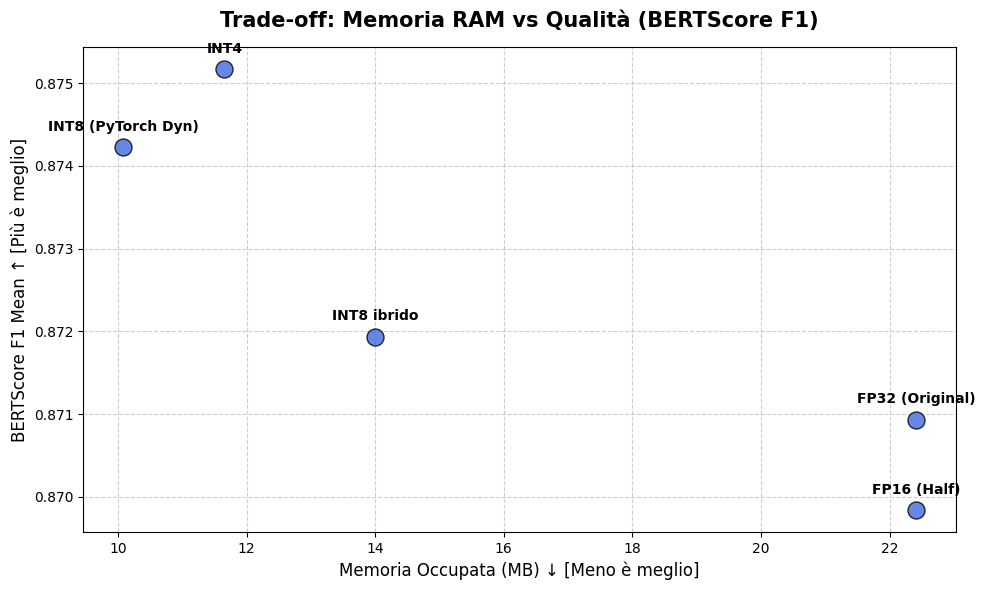

In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. Funzione universale per calcolare la memoria (MB) di un modello PyTorch
def calcola_memoria_mb(modello):
    param_size = 0
    for param in modello.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in modello.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    return (param_size + buffer_size) / (1024 ** 2)

data_points = [
    ("FP32 (Original)", calcola_memoria_mb(model_fp32), metriche_fp_32['F1_Mean']),
    ("FP16 (Half)", calcola_memoria_mb(model_fp16), metriche_fp_16['F1_Mean']),
    ("INT8 (PyTorch Dyn)", calcola_memoria_mb(model_quantized), metriche_int_8['F1_Mean']),
    ("INT8 ibrido", calcola_memoria_mb(model_ibrido), metriche_ibrido['F1_Mean']),
    ("INT4", calcola_memoria_mb(model_int4), metriche_int_4['F1_Mean'])
]

names = []
memories_mb = []
f1_scores = []

for name, mem_mb, f1 in data_points:
    names.append(name)
    memories_mb.append(mem_mb)
    f1_scores.append(f1)

plt.figure(figsize=(10, 6))

plt.scatter(memories_mb, f1_scores, color='royalblue', s=150, alpha=0.8, edgecolors='black', zorder=5)

for i, name in enumerate(names):
    plt.annotate(
        name,
        (memories_mb[i], f1_scores[i]),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Trade-off: Memoria RAM vs Qualità (BERTScore F1)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Memoria Occupata (MB) ↓ [Meno è meglio]', fontsize=12)
plt.ylabel('BERTScore F1 Mean ↑ [Più è meglio]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()